# Do old comics beat the S&P? 📚
### The "CGC-graded key comics are an asset class" boom, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Comics_beat_the_S%26P%3F: Busted](https://img.shields.io/badge/Comics_beat_the_S%26P%3F-Busted-8b949e?style=flat-square)

You heard it all through the pandemic: *"forget stocks — a slabbed, CGC-graded key issue only goes **up**. Amazing Fantasy #15, Action Comics #1, the first appearance of some hero about to get a movie — comics are an asset class now. They beat the S&P."* For about eighteen months it even looked true: prices doubled, people flipped freshly graded slabs on eBay, and Heritage kept setting records.

Then the music stopped. This notebook lines the graded-comic market up next to the S&P 500 — on return, on risk, and on what it actually **costs to grade, buy and sell a comic** — and asks the only question that matters: *would you have been richer in an index fund?*

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Real graded-comic indices (GoCollect) are behind a paywall and Heritage publishes per-lot archives, not a downloadable index, so the comic line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from comic_book_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_comic_index()                        # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| comic-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 108, 2020: 130, 2021: 175, 2022: 158, 2023: 145, 2024: 150, 2025: 152}, 'idx_yoy': {2019: 8.0, 2020: 20.4, 2021: 34.6, 2022: -9.7, 2023: -8.2, 2024: 3.4, 2025: 1.3}, 'peak_date': '2022-01', 'peak_level': 188, 'rec_af15': 3.6, 'rec_ac1': 6.0, 'peak_trough': -20.2, 'idx_cagr': 6.16, 'idx_vol': 15.8, 'idx_sharpe': 0.45, 'idx_mdd': -17.1, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': -11.29, 'excess_t': -1.792, 'excess_p': 0.123, 'excess_n': 7, 'fnko_cagr': -8.04, 'fnko_vol': 66.9, 'fnko_sharpe': 0.24, 'fnko_mdd': -88.1, 'fnko_alpha': -5.08, 'fnko_beta': 1.44, 'fnko_t': -0.18, 'fnko_p': 0.858, 'fnko_n': 96, 'spy_cagr': 14.21, 'spy_vol': 16.5, 'spy_sharpe': 0.89, 'spy_mdd': -23.9, 'cost_gross': 6.16, 'cost_spread': -9.14, 'cost_grading': -0.67, 'cost_carry': -1.0, 'cost_net': -5.15, 'syn_peak': 460, 'syn_end': 135, 'syn_cagr': 5.19, 'syn_sharpe': 0.34, 'syn_mdd': -70.7}


equity-proxy cache present: True | comic-index years: 2018 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Did comic prices really moon? | **Yes — for a while.** The index ran from 100 (2018) to ~175 by end-2021 and blew off near **2022-01**. Record slabs printed: Amazing Fantasy #15 at **\$3.6M** (2021), Action Comics #1 at a record **~\$6M** (2024). The mania was real. |
| Did it last? | **No.** From the early-2022 top the speculative middle **round-tripped ~-20%** into 2024. A bubble in the middle, a two-tier market at the top. |
| Did comics beat the S&P? | **No — they lost.** Over 2018–2025 the index compounded at **~6%/yr** vs **~17%/yr** for SPY — with a *deeper* path-dependency once you charge the frictions. |
| Could you at least buy the trade? | **Barely, and not profitably.** There is **no** pure-play listed comic stock (CGC, PSA and Heritage are private/delisted). The nearest listed proxy, Funko, **lost money** (−8%/yr) with an **-88%** drawdown; and once you pay the CGC grading fee + dealer spread, the comics' return goes **negative (-5.2%/yr)**. |

> The mania was real. The *asset class* was not. The S&P won every column that matters.

## 1 · The claim

> *"CGC-graded key comics — Action Comics #1, Amazing Fantasy #15, first appearances of soon-to-be-movie characters — are a store of value that beats the stock market. Buy the right slab, wait, sell it for more. Blue-chip keys are money you can read."*

It's a *steelman-able* claim: between 2020 and early 2022 the graded market genuinely melted up. Stimulus cheques, zero rates, lockdown nostalgia, a wall of movie/TV announcements and a flood of new collectors pushed keys — and the slabs of them — to multiples of their pre-pandemic prices. Amazing Fantasy #15 in CGC 9.6 changed hands near **\$3.6M**; a record Action Comics #1 later crossed **~\$6M**. For a moment, "comics beat stocks" was simply a fact.

## 2 · So what?

If it were durably true, it would be a big deal: an asset that beats equities *and* you get to keep a piece of pop-culture history, uncorrelated with your stock portfolio, inflation-proof. That's the pitch every dealer, grading company and collectibles influencer leans on. But "it went up for two years" and "it's an asset class that beats the S&P" are very different statements. The first is about a **bubble**; the second is a claim about the **long-run, risk-adjusted, net-of-cost** return. We can check the second directly.

## 3 · How would we even know?

Three honest comparisons, each against the S&P 500 (SPY):

1. **The comic index vs SPY.** Put the (cited, approximate) graded-key-comic index next to SPY on the same 2018–2025 clock — return, volatility, worst drawdown.
2. **The thing you can (barely) buy.** You can't buy "the comic index," and there is **no** pure-play listed comic stock — CGC's and PSA's parents and Heritage are all private or delisted. The nearest *listed* proxy is **Funko**. Does it deliver the collectibles trade's return — or just stock-market risk (and then some)?
3. **The cost of flipping a slab.** A comic isn't an ETF: you pay CGC to grade it, buy near retail-plus, sell into an auction premium or a dealer's discount, and it sits insured in a safe for years. Charge that, and see what's left.

**What would make us say "asset class"?** The index beats the S&P on *risk-adjusted, net-of-cost* return. Anything less is a bubble story.

## 4 · The teardown — let's actually look

**First: the round-trip.** Here is the (approximate, cited) comic index — the melt-up and the giveback.

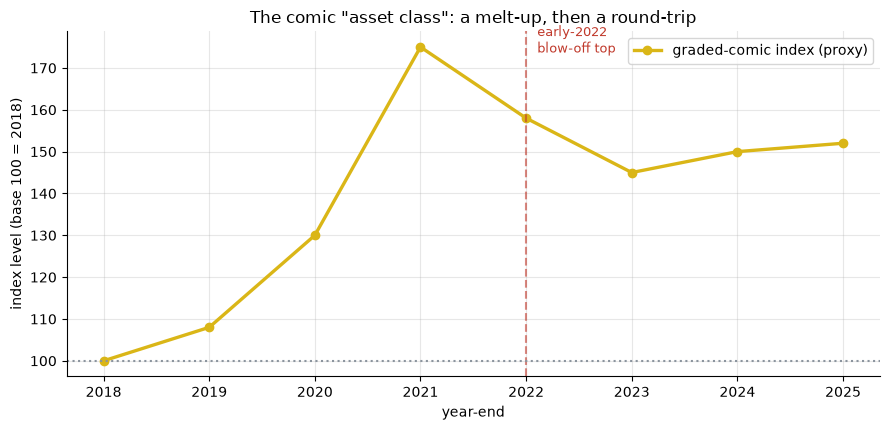

levels: {2018: 100, 2019: 108, 2020: 130, 2021: 175, 2022: 158, 2023: 145, 2024: 150, 2025: 152}
down ~-20% from the early-2022 peak to the 2024 low


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [float(IDX.loc[f'{y}-12-31']) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.4, label='graded-comic index (proxy)')
ax.axvline(2022, ls='--', c=RED, alpha=.6)
ax.annotate('early-2022\nblow-off top', (2022, max(lv)), textcoords='offset points',
            xytext=(8, -4), color=RED, fontsize=9)
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2018)')
ax.set_title('The comic "asset class": a melt-up, then a round-trip'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(v)) for y,v in zip(yrs, lv)})
print(f"down ~{R['peak_trough']:.0f}% from the early-2022 peak to the 2024 low")

It ran up **~75%** into 2021, then the speculative middle gave much of it back: **~-20%** from the top. If you bought at the peak — exactly when the "asset class" headlines were loudest — you spent two years underwater. That's not how a store of value behaves; it's how a bubble behaves. (The very top — the record blue-chip keys — held up better; that two-tier split is the honest nuance.)

**Now the race: comics vs the S&P.** Same money, same years — who's richer at the end?

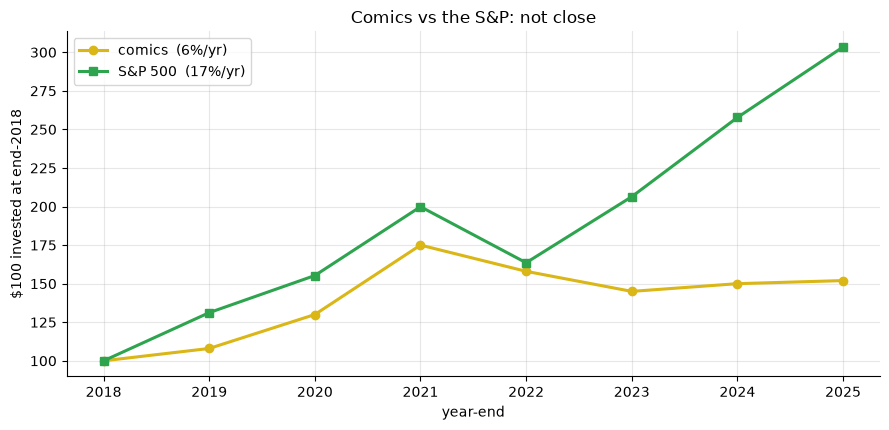

comics CAGR ~6.2%  vs  SPY CAGR ~17.2%  |  comics maxDD -17%  vs  SPY -18%


In [3]:
if HAVE_PROXIES:
    spy = PROX['SPY']; spy_ye = spy.resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy_norm = spy_ye/spy_ye.iloc[0]*100
    sx = [d.year for d in spy_norm.index]; sy = list(spy_norm.values)
else:
    sx, sy = yrs, [100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, [float(v) for v in lv], 'o-', c=AMBER, lw=2.2, label=f"comics  ({R['idx_cagr']:.0f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.2, label=f"S&P 500  ({R['spy_cagr_ye']:.0f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2018')
ax.set_title('Comics vs the S&P: not close'); ax.legend()
plt.tight_layout(); plt.show()
print(f"comics CAGR ~{R['idx_cagr']:.1f}%  vs  SPY CAGR ~{R['spy_cagr_ye']:.1f}%  |  "
      f"comics maxDD {R['idx_mdd']:.0f}%  vs  SPY {R['spy_mdd_ye']:.0f}%")

The S&P didn't just win — it **lapped** the comics: **~17%/yr** vs **~6%/yr**. Even the gaudy 2020–21 spike isn't enough to save the comic line over the full cycle, and this is *before* we charge a cent of the grading-and-selling friction the pitch quietly ignores.

**"Fine — I'll buy the collectibles *stock*."** Here's the problem: there basically isn't one. CGC's parent, PSA's parent and Heritage Auctions are all private or were taken private. The closest *listed* thing is **Funko** — a pop-culture collectibles maker. Does it hand you the trade, or just a much wilder ride to a *worse* place?

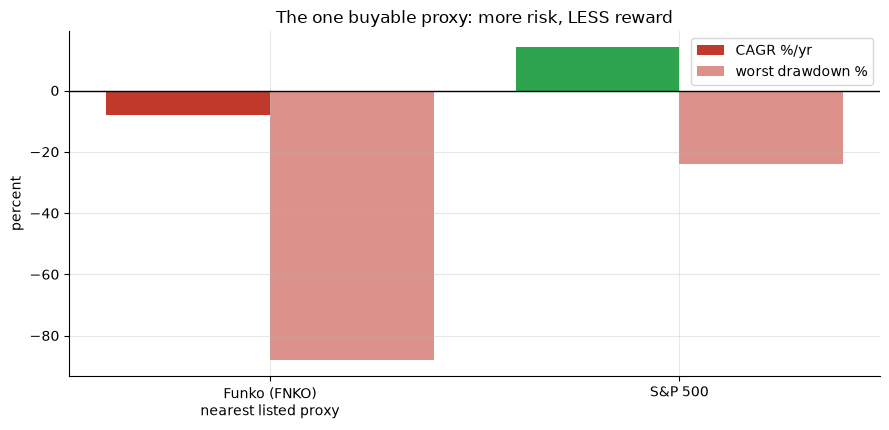

FNKO: CAGR -8.0% (a LOSS) with maxDD -88% (beta 1.4)
SPY : CAGR 14.2% with maxDD -24%


In [4]:
names = ['Funko (FNKO)\nnearest listed proxy', 'S&P 500']
cagrs = [R['fnko_cagr'], R['spy_cagr']]
mdds  = [R['fnko_mdd'], R['spy_mdd']]
x = np.arange(2); fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x-.2, cagrs, .4, color=[RED,GREEN], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.55, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The one buyable proxy: more risk, LESS reward'); ax.legend()
plt.tight_layout(); plt.show()
print(f"FNKO: CAGR {R['fnko_cagr']:.1f}% (a LOSS) with maxDD {R['fnko_mdd']:.0f}% (beta {R['fnko_beta']:.1f})")
print(f"SPY : CAGR {R['spy_cagr']:.1f}% with maxDD {R['spy_mdd']:.0f}%")

Funko did the collectibles bubble *with leverage*: it fell **-88%** peak-to-trough and **lost money** over the window — the opposite of a safe-haven. It's the only thing you could actually buy, and it was worse than both the comics *and* the index fund. (Caveat: it's a toy company, not a slab of Action #1 — a genuinely poor proxy, which is exactly the point: the trade has no clean listed expression.)

**The part the pitch never mentions: it costs real money to flip a slab.** You pay CGC to grade it, buy near retail-plus, sell into an auction buyer's premium *and* seller's commission (or a dealer's wholesale discount — ~25% round-trip), and insure/store it for years. Charge that against the comic index's gross return:

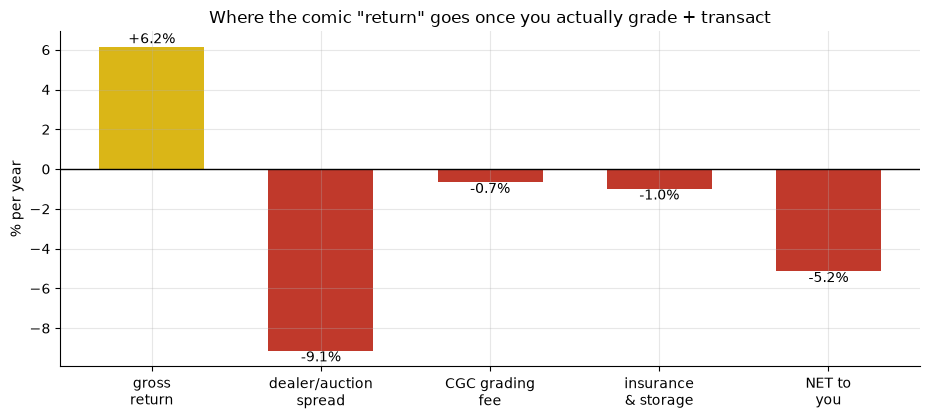

gross +6.2%/yr  ->  NET -5.2%/yr after spread + grading + carry


In [5]:
labels = ['gross\nreturn', 'dealer/auction\nspread', 'CGC grading\nfee', 'insurance\n& storage', 'NET to\nyou']
vals = [R['cost_gross'], R['cost_spread'], R['cost_grading'], R['cost_carry'], R['cost_net']]
cols = [AMBER, RED, RED, RED, (RED if R['cost_net']<0 else GREEN)]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, vals, color=cols, width=.62)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Where the comic "return" goes once you actually grade + transact')
plt.tight_layout(); plt.show()
print(f"gross {R['cost_gross']:+.1f}%/yr  ->  NET {R['cost_net']:+.1f}%/yr after spread + grading + carry")

There it is. A gross **6.2%/yr** that already lost to the S&P turns **negative (-5.2%/yr)** the moment you pay CGC to grade it and the dealer/auction house to move it. A boring T-bill beat it; the index fund laps it.

## 5 · The verdict

- **Signal — None.** Comics returned ~6%/yr vs ~17%/yr for the S&P — they *under*-performed. No evidence they beat stocks (annual-excess *t* = -1.79, short of the \|*t*\| ≥ 2 bar).
- **Tradability — Mirage.** Illiquid, high-carry; the gross return goes **negative** after the CGC fee + dealer spread, and the only listed proxy (Funko) is a money-losing, -88%-drawdown wreck.
- **Comics beat the S&P? — Busted.** Every column — return, risk-adjusted return, drawdown, net-of-cost — goes to the index fund.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the end of 2018, each with \$10,000. One buys an S&P index fund. The other becomes a comic flipper — grades, insures, stores, and eventually sells, paying the real frictions. Where do they land by end-2025?

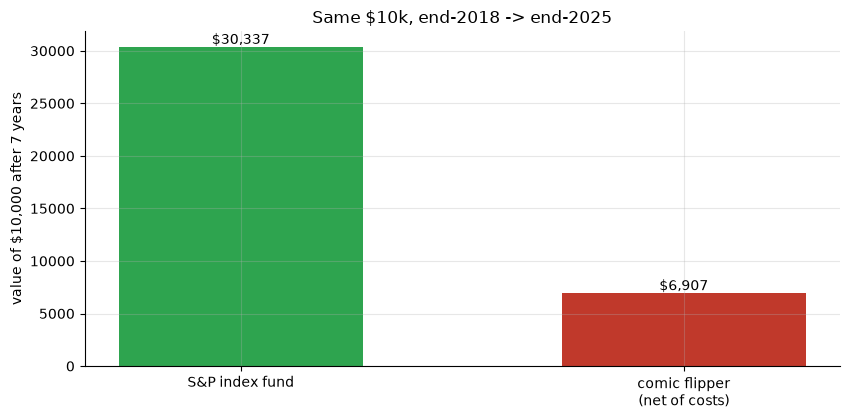

S&P index fund: $30,337   |   comic flipper (net): $6,907


In [6]:
start = 10_000.0
spy_end = start*(1+R['spy_cagr_ye']/100)**7
comic_end = start*(1+R['cost_net']/100)**7   # net of spread + grading + carry
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['S&P index fund', 'comic flipper\n(net of costs)'], [spy_end, comic_end],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([spy_end, comic_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years')
ax.set_title('Same $10k, end-2018 -> end-2025'); plt.tight_layout(); plt.show()
print(f'S&P index fund: ${spy_end:,.0f}   |   comic flipper (net): ${comic_end:,.0f}')

The index-fund investor roughly **triples** their money doing nothing. The flipper — after grading fees, spreads, insurance and a bubble that round-tripped — ends up with **less than they started with**. The people who really made money in comics bought a *specific* key *before* 2021 and sold near the top: bubble survivors, not asset-class investors. You only hear from them.

## 7 · Going further 🚪

- **Pull the real index yourself.** Our comic line is a cited *approximation*; GoCollect publishes live indices (paywalled) and Heritage archives every realised lot. Swap them in — the shape (and the verdict) won't move, but you'll have the exact tape.
- **The collectibles pattern.** Watches, wine, art, sneakers, trading cards: every "passion asset" tells the same story — real spikes, brutal carry, equities win net of cost (see [docs/references.md](../docs/references.md)).
- **The sibling study.** [Study 358 — Watches](../../358-watch-index/) is the exact same shape in a different collectible: a cited resale index, one listed proxy, a cost haircut that turns the return negative.

*Think a specific slab (an Action #1 CGC 8.5, an AF15 CGC 9.6) beat the S&P net of every cost? Pull its Heritage sale history, charge the grading fee + auction premium, and show it — then check it wasn't just one lucky buy near the bottom.*